# Lab Based Project: Urban Green Mapping of Bhubaneshwar City
---

## Methodology

### Overview
This analysis follows a supervised machine learning pipeline to classify urban land cover in Bhubaneswar across five temporal snapshots (2021,2023,2024,2025,2026), using multispectral satellite imagery from PlanetScope. The goal is to map the spatial distribution of green spaces and detect how they have changed over time.

---

### Step 1: Data Acquisition
Multispectral surface reflectance imagery was acquired from **PlanetScope's SuperDove sensor**, which captures 8 spectral bands: Coastal Blue, Blue, Green I, Green, Yellow, Red, Red Edge, and Near-Infrared (NIR). Images were downloaded for five years at approximately consistent seasonal windows to minimise phenological variation across time. All images cover the administrative extent of Bhubaneswar Municipal Corporation.

---

### Step 2: Training Data Collection (QGIS)
Ground truth training points were manually digitized in **QGIS** by visually interpreting the composite raster imagery. Approximately **1000 points** were collected across three land cover classes:

- **Forest** — dense tree canopy, deep green in appearance
- **Shrub** — low vegetation including grass, scrub, and parks
- **Developed** — impervious surfaces including roads, buildings, and bare ground

Points were saved as **GeoJSON files** and exported for use in Python. QGIS was used exclusively for digitizing and visual inspection; all analytical steps were performed in Python.

---

### Step 3: Feature Engineering
For each training point and subsequently each pixel in the raster, a feature vector was constructed consisting of:

- **8 raw spectral bands** (surface reflectance values, scaled 0–1)
- **5 derived spectral indices** known to discriminate vegetation cover:
  - **NDVI** (Normalized Difference Vegetation Index) — general vegetation density
  - **NDRE** (Normalized Difference Red Edge) — canopy chlorophyll, sensitive to vegetation stress
  - **GNDVI** (Green NDVI) — vegetation vigour using green band
  - **EVI** (Enhanced Vegetation Index) — reduces soil and atmospheric noise
  - **SAVI** (Soil Adjusted Vegetation Index) — reduces soil brightness effect, useful in sparse vegetation areas

This gives each pixel a **13-dimensional feature vector**. The use of spectral indices as supplementary features is well-supported in the literature, with studies on PlanetScope specifically identifying NDRE and GNDVI as top predictors for vegetation classification.

---

### Step 4: Sample Extraction
Band values and derived indices were sampled at each training point location by intersecting the point geometries with the raster pixel grid using `rasterio`. Points falling outside the raster extent or on nodata pixels were excluded. The resulting dataset was a tabular matrix of shape **(n_points × 13 features)** with an associated class label column.

---

### Step 5: Model Training
A **Random Forest classifier** was trained on the extracted samples using `scikit-learn`. Random Forest was chosen over SVM for the following reasons:

- Handles high-dimensional feature spaces efficiently
- Scales well to large raster inference (millions of pixels)
- Robust to outliers and class imbalance
- Provides interpretable feature importance scores
- Consistently outperforms SVM in remote sensing classification benchmarks

The dataset was split **80/20 into training and test sets** with stratified sampling to preserve class proportions. Model performance was evaluated using overall accuracy, per-class precision/recall/F1, and a confusion matrix.

---

### Step 6: Raster Classification
The trained model was applied to each of the five yearly rasters to produce **land cover classification maps**. Each raster was read band-by-band, spectral indices were computed on the full pixel grid, and the 13-band feature stack was passed through the classifier pixel-by-pixel. The output is a single-band classified raster with integer codes corresponding to Forest, Shrub, and Developed classes. Classified rasters were saved as GeoTIFF files.

---

### Step 7: Change Detection
Change was analysed both **statistically** and **spatially**:

- **Area statistics** — the total area (km²) of each class was computed for each year and plotted as a time series to reveal broad trends in green space coverage
- **Transition matrices** — a pixel-wise cross-tabulation between any two years reveals how many pixels transitioned between classes (e.g. Forest → Developed)
- **Spatial change maps** — a per-pixel comparison between the 2018 and 2026 classifications highlights *where* change occurred, distinguishing between green gain, green loss, and forest degradation

---

### Tools & Libraries

| Tool | Purpose |
|---|---|
| QGIS | Training point digitization |
| `rasterio` | Raster I/O and pixel sampling |
| `geopandas` | Vector point file handling |
| `numpy` | Array operations and index computation |
| `scikit-learn` | Random Forest training and evaluation |
| `matplotlib` / `seaborn` | Visualisation and mapping |
| `joblib` | Model serialisation |
| Google Colab | Compute environment |


## Points Classes
| class | value |
| ----- | ------|
| construction | 0 |
| water | 1 |
| grasslands/light vegetation | 2 |
| forests/trees/deep vegetation | 3 |





In [ ]:
!pip install rasterio
!pip install geopandas

In [ ]:
# imports and drive setup
# Install dependencies (run once)
# pip install rasterio geopandas scikit-learn matplotlib numpy pandas seaborn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import rasterio
from rasterio.plot import show
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# drive setup
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# check if drive loaded correctly
!cat /content/drive/My\ Drive/urbangreen/feature.geojson

{
  "type": "Feature",
  "geometry": {
    "coordinates": [
      [
        [
          85.77934075,
          20.2391446
        ],
        [
          85.7532935,
          20.26720179
        ],
        [
          85.75561548,
          20.27961586
        ],
        [
          85.76514072,
          20.3081469
        ],
        [
          85.80358347,
          20.35587597
        ],
        [
          85.8142189,
          20.3644401
        ],
        [
          85.81756941,
          20.36625858
        ],
        [
          85.82201768,
          20.36639941
        ],
        [
          85.8222411,
          20.36640056
        ],
        [
          85.82240339,
          20.3663926
        ],
        [
          85.89724914,
          20.36178798
        ],
        [
          85.90292527,
          20.352454
        ],
        [
          85.90315182,
          20.35187708
        ],
        [
          85.90339893,
          20.35082714
        ],
        [
       

In [ ]:
# filenames and paths
composite_2025 = '/content/drive/My Drive/urbangreen/2025/composite.tif'
composite_2023 = '/content/drive/My Drive/urbangreen/2023/composite.tif'
composite_2021 = '/content/drive/My Drive/urbangreen/2021/composite.tif'

composite_2024 = '/content/drive/My Drive/urbangreen/2024/composite.tif' # 8 band
composite_2026 = '/content/drive/My Drive/urbangreen/2026/composite.tif' # 8 band

water_geojson = '/content/drive/My Drive/urbangreen/water.geojson'
construction_geojson = '/content/drive/My Drive/urbangreen/construction.geojson'
light_geojson = '/content/drive/My Drive/urbangreen/light.geojson'
dark_geojson = '/content/drive/My Drive/urbangreen/dark.geojson'

feature_geojson = '/content/drive/My Drive/urbangreen/feature.geojson'


In [ ]:
# load geojson files
water = gpd.read_file(water_geojson)
construction = gpd.read_file(construction_geojson)
light = gpd.read_file(light_geojson)
dark = gpd.read_file(dark_geojson)

print(water)
print(construction)
print(light)
print(dark)

     class  value                   geometry
0    water      1  POINT (85.83499 20.24119)
1    water      1  POINT (85.83547 20.24124)
2    water      1  POINT (85.83471 20.24224)
3    water      1  POINT (85.83488 20.24292)
4    water      1  POINT (85.83497 20.24323)
..     ...    ...                        ...
183  water      1  POINT (85.87217 20.34841)
184  water      1  POINT (85.87264 20.34896)
185  water      1  POINT (85.87189 20.34752)
186  water      1  POINT (85.87169 20.34703)
187  water      1   POINT (85.8717 20.34523)

[188 rows x 3 columns]
            class  value                   geometry
0    construction      0  POINT (85.79333 20.28074)
1    construction      0  POINT (85.79337 20.28042)
2    construction      0  POINT (85.79331 20.28053)
3    construction      0  POINT (85.79371 20.28038)
4    construction      0  POINT (85.79371 20.28045)
..            ...    ...                        ...
348  construction      0  POINT (85.80949 20.28306)
349  construction   

In [ ]:
# merge geojson
merged = gpd.GeoDataFrame(pd.concat([water, construction, light, dark], ignore_index=True), crs=water.crs)
merged

,class,value,geometry
0,water,1,POINT (85.83499 20.24119)
1,water,1,POINT (85.83547 20.24124)
2,water,1,POINT (85.83471 20.24224)
3,water,1,POINT (85.83488 20.24292)
4,water,1,POINT (85.83497 20.24323)
...,...,...,...
1142,dark,3,POINT (85.85359 20.34524)
1143,dark,3,POINT (85.85375 20.34551)
1144,dark,3,POINT (85.85282 20.34463)
1145,dark,3,POINT (85.85956 20.33883)


In [ ]:
# create test_train_split
train_gdf, test_gdf = train_test_split(merged, test_size=0.2, random_state=42, stratify=merged['class'])
print(train_gdf)
print(test_gdf)

             class  value                   geometry
428   construction      0  POINT (85.81885 20.29396)
366   construction      0  POINT (85.80905 20.29008)
477   construction      0  POINT (85.81816 20.28956)
1145          dark      3  POINT (85.85956 20.33883)
927           dark      3  POINT (85.78395 20.27492)
...            ...    ...                        ...
624          light      2  POINT (85.87611 20.29577)
9            water      1  POINT (85.83515 20.24076)
1109          dark      3  POINT (85.82147 20.31424)
492   construction      0  POINT (85.81751 20.28166)
419   construction      0   POINT (85.81787 20.2942)

[917 rows x 3 columns]
             class  value                   geometry
287   construction      0  POINT (85.79828 20.28024)
851           dark      3  POINT (85.78389 20.30693)
713          light      2  POINT (85.80446 20.34113)
236   construction      0  POINT (85.79612 20.28167)
309   construction      0  POINT (85.79793 20.27932)
...            ...    

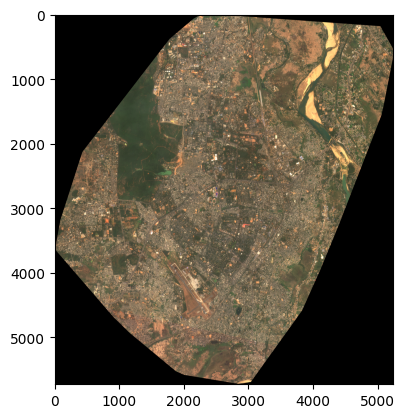

In [ ]:
# visualise 2026 raster

with rasterio.open(composite_2026) as src:
    red   = src.read(6).astype(float)  # b6
    green = src.read(4).astype(float)  # b4
    blue  = src.read(2).astype(float)  # b2
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# def normalize(array):
#     array_min, array_max = array.min(), array.max()
#     return (array - array_min) / (array_max - array_min)

def normalize(band,min=0,max=2000):
    # p2, p98 = np.percentile(band, 2), np.percentile(band, 98)
    return np.clip((band - min) / (max - min), 0, 1)


rgb = np.dstack([normalize(red), normalize(green), normalize(blue)])

plt.imshow(rgb)

In [ ]:
src = rasterio.open(composite_2026)
src

<open DatasetReader name='/content/drive/My Drive/urbangreen/2026/composite.tif' mode='r'>

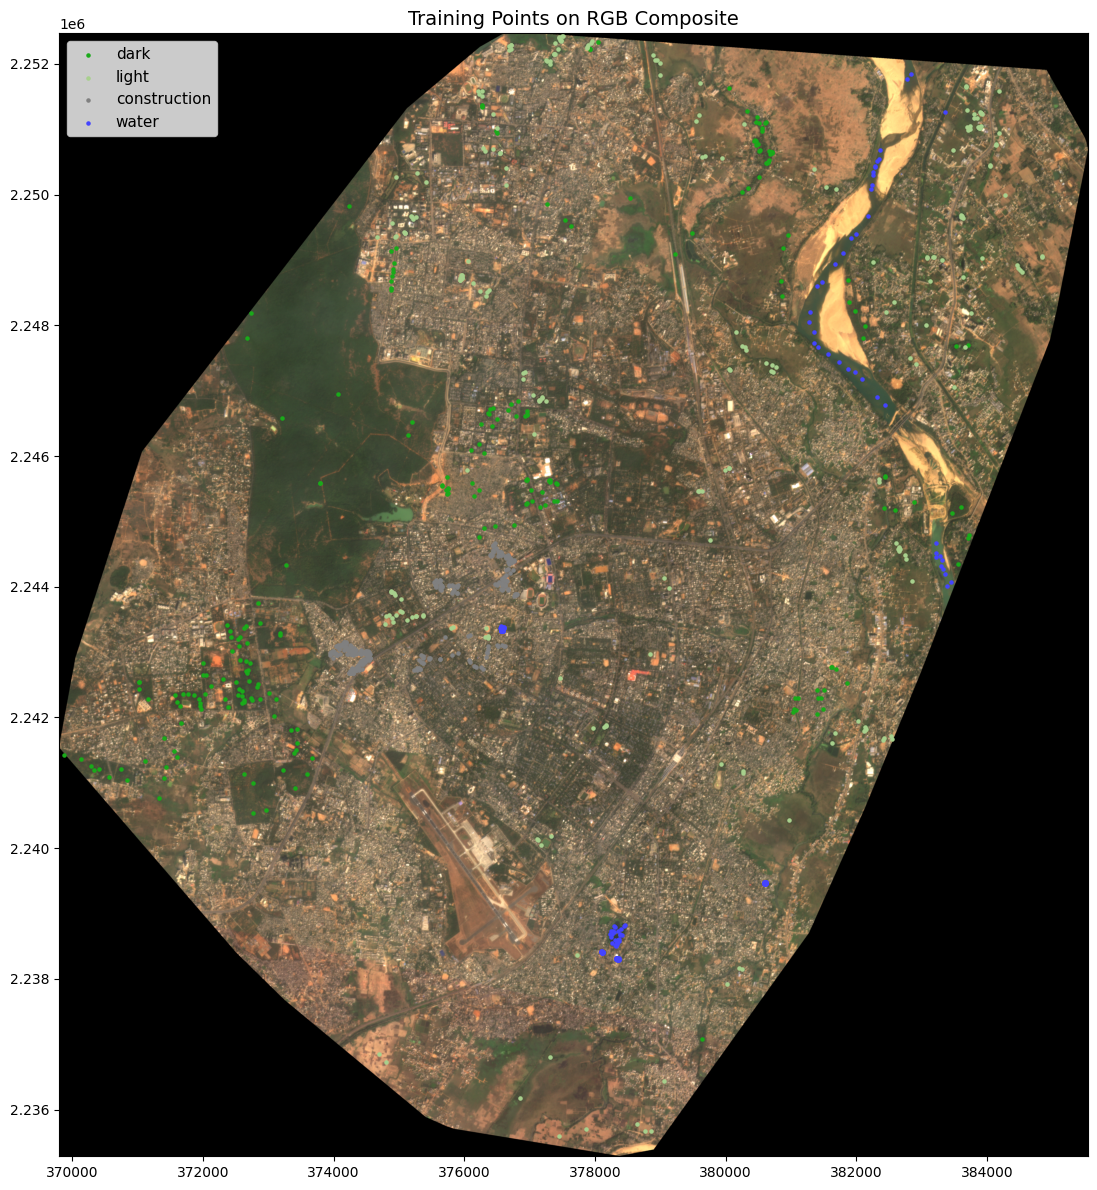

In [ ]:
with rasterio.open(composite_2026) as src:
    red   = src.read(6).astype(float)  # b6
    green = src.read(4).astype(float)  # b4
    blue  = src.read(2).astype(float)  # b2
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

rgb = np.dstack([normalize(red), normalize(green), normalize(blue)])

# Reproject points to raster CRS if needed
train_plot = train_gdf.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgb, extent=extent)

# Plot each class in a different color
colors = {'dark': '#1aaa1a', 'light': '#a8d08d', 'construction': '#808080', 'water': '#4444ff'}
for label, color in colors.items():
    subset = train_plot[train_plot['class'] == label]
    subset.plot(ax=ax, color=color, markersize=5, label=label)

ax.legend(fontsize=11)
ax.set_title("Training Points on RGB Composite", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
train_gdf.iloc[0]

,428
class,construction
value,0
geometry,POINT (85.81885468468924 20.293956708809883)


In [ ]:
from rasterio.transform import rowcol
BAND_NAMES = ['CoastalBlue', 'Blue', 'GreenI', 'Green', 'Yellow', 'Red', 'RedEdge', 'NIR']

def compute_indices(bands):
    nir = bands['NIR']
    red = bands['Red']
    re  = bands['RedEdge']
    grn = bands['Green']
    blu = bands['Blue']
    eps = 1e-10

    return {
        'NDVI':  (nir - red) / (nir + red + eps),
        'NDRE':  (nir - re)  / (nir + re  + eps),
        'GNDVI': (nir - grn) / (nir + grn + eps),
        'EVI':   2.5 * (nir - red) / (nir + 6*red - 7.5*blu + 1 + eps),
        'SAVI':  1.5 * (nir - red) / (nir + red + 0.5 + eps),
    }

def extract_samples(raster_path, gdf):
    rows_list = []

    with rasterio.open(raster_path) as src:
        # Reproject points to raster CRS
        gdf_proj = gdf.to_crs(src.crs)
        data = src.read().astype(float)  # (8, H, W)
        H, W = data.shape[1], data.shape[2]

        for _, point in gdf_proj.iterrows():
            x, y = point.geometry.x, point.geometry.y

            # Get pixel row/col for this point
            row, col = rowcol(src.transform, x, y)

            # Skip if outside raster bounds
            if not (0 <= row < H and 0 <= col < W):
                continue

            # Get band values at this pixel
            pixel = data[:, row, col]

            # Skip nodata pixels
            if src.nodata and np.any(pixel == src.nodata):
                continue

            bands = {name: pixel[i] for i, name in enumerate(BAND_NAMES)}
            indices = compute_indices(bands)

            rows_list.append({**bands, **indices, 'class': point['class']})

    return pd.DataFrame(rows_list)

# Extract samples from the 2022 raster (or whichever year you digitized against)
samples_df = extract_samples(composite_2026, train_gdf)

print(samples_df.shape)
print(samples_df['class'].value_counts())
samples_df.head(20)

(917, 14)
class
construction    282
light           245
dark            240
water           150
Name: count, dtype: int64


,CoastalBlue,Blue,GreenI,Green,Yellow,Red,RedEdge,NIR,NDVI,NDRE,GNDVI,EVI,SAVI,class
0,632.0,752.0,881.0,936.0,1070.0,1169.0,1321.0,1776.0,0.206112,0.146916,0.309735,0.481593,0.309116,construction
1,857.0,1143.0,1246.0,1415.0,1443.0,1694.0,1787.0,2290.0,0.149598,0.123375,0.236167,0.383773,0.224369,construction
2,535.0,637.0,706.0,793.0,928.0,953.0,1213.0,1788.0,0.304633,0.191603,0.385509,0.764792,0.456867,construction
3,329.0,418.0,500.0,569.0,573.0,552.0,975.0,2104.0,0.584337,0.366677,0.574261,1.700263,0.876341,dark
4,399.0,479.0,542.0,619.0,588.0,613.0,952.0,1928.0,0.517513,0.338889,0.513938,1.631919,0.776116,dark
5,397.0,444.0,543.0,604.0,610.0,580.0,913.0,1923.0,0.536556,0.356135,0.521963,1.618852,0.804673,dark
6,605.0,683.0,757.0,839.0,948.0,1002.0,1170.0,1614.0,0.233945,0.159483,0.315940,0.610900,0.350850,construction
7,454.0,624.0,882.0,990.0,917.0,788.0,1612.0,3086.0,0.593185,0.313751,0.514230,1.832536,0.889663,light
8,881.0,1091.0,1213.0,1370.0,1404.0,1579.0,1698.0,2073.0,0.135268,0.099443,0.204182,0.366959,0.202875,construction
9,504.0,587.0,725.0,817.0,850.0,889.0,1316.0,2731.0,0.508840,0.349642,0.539459,1.256995,0.763154,light


In [ ]:
# split into class and features table
FEATURE_COLS = BAND_NAMES + ['NDVI', 'NDRE', 'GNDVI', 'EVI', 'SAVI']

X_train = samples_df[FEATURE_COLS].values
y_train = samples_df['class'].values

X_train

array([[6.32000000e+02, 7.52000000e+02, 8.81000000e+02, ...,
        3.09734513e-01, 4.81593145e-01, 3.09115600e-01],
       [8.57000000e+02, 1.14300000e+03, 1.24600000e+03, ...,
        2.36167341e-01, 3.83773342e-01, 2.24369432e-01],
       [5.35000000e+02, 6.37000000e+02, 7.06000000e+02, ...,
        3.85509492e-01, 7.64792086e-01, 4.56866679e-01],
       ...,
       [3.72000000e+02, 4.45000000e+02, 5.05000000e+02, ...,
        5.04888889e-01, 1.83085207e+00, 7.77404169e-01],
       [5.89000000e+02, 7.06000000e+02, 8.57000000e+02, ...,
        3.87827110e-01, 5.22590361e-01, 4.24378312e-01],
       [5.26000000e+02, 5.82000000e+02, 6.65000000e+02, ...,
        4.25436814e-01, 1.10572484e+00, 5.63418937e-01]])

In [ ]:
# generate feature samples for test data too
samples_test_df = extract_samples(composite_2026, test_gdf)
print(samples_test_df.shape)
print(samples_test_df['class'].value_counts())
samples_test_df.head(20)

(230, 14)
class
construction    71
light           61
dark            60
water           38
Name: count, dtype: int64


,CoastalBlue,Blue,GreenI,Green,Yellow,Red,RedEdge,NIR,NDVI,NDRE,GNDVI,EVI,SAVI,class
0,674.0,766.0,897.0,1053.0,1152.0,1162.0,1426.0,2036.0,0.273296,0.176199,0.318226,0.669424,0.409880,construction
1,279.0,353.0,468.0,506.0,453.0,425.0,973.0,2675.0,0.725806,0.466557,0.681861,2.181501,1.088534,dark
2,513.0,578.0,791.0,853.0,838.0,847.0,1457.0,3317.0,0.593180,0.389610,0.590887,1.519065,0.889663,light
3,669.0,800.0,845.0,953.0,1075.0,1116.0,1311.0,1718.0,0.212421,0.134368,0.286410,0.623188,0.318575,construction
4,499.0,576.0,717.0,808.0,825.0,840.0,1274.0,2559.0,0.505737,0.335247,0.520048,1.310213,0.758494,construction
5,771.0,954.0,1009.0,1051.0,1050.0,1150.0,1276.0,2078.0,0.287485,0.239117,0.328220,1.271930,0.431160,construction
6,533.0,679.0,733.0,864.0,944.0,1004.0,1244.0,1850.0,0.296426,0.195863,0.363301,0.760108,0.444561,dark
7,777.0,895.0,987.0,1047.0,1059.0,1178.0,1265.0,1722.0,0.187586,0.152996,0.243770,0.654318,0.281331,construction
8,472.0,516.0,612.0,644.0,604.0,609.0,996.0,2202.0,0.566702,0.377111,0.547435,2.004278,0.849902,dark
9,501.0,603.0,706.0,784.0,814.0,880.0,1075.0,1685.0,0.313840,0.221014,0.364925,0.823614,0.470668,construction


In [ ]:
X_test = samples_test_df[FEATURE_COLS].values
y_test = samples_test_df['class'].values

X_test

array([[6.74000000e+02, 7.66000000e+02, 8.97000000e+02, ...,
        3.18225963e-01, 6.69424020e-01, 4.09879631e-01],
       [2.79000000e+02, 3.53000000e+02, 4.68000000e+02, ...,
        6.81861050e-01, 2.18150087e+00, 1.08853411e+00],
       [5.13000000e+02, 5.78000000e+02, 7.91000000e+02, ...,
        5.90887290e-01, 1.51906519e+00, 8.89662625e-01],
       ...,
       [4.43000000e+02, 5.20000000e+02, 6.89000000e+02, ...,
        5.85410653e-01, 1.85328490e+00, 9.52645109e-01],
       [7.45000000e+02, 8.66000000e+02, 9.92000000e+02, ...,
        2.49116040e-01, 3.47921508e-01, 2.41523525e-01],
       [3.55000000e+02, 4.40000000e+02, 5.39000000e+02, ...,
        5.48621190e-01, 1.38414408e+00, 8.05220522e-01]])

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# train model
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['dark', 'light', 'construction','water']))

              precision    recall  f1-score   support

        dark       0.88      0.99      0.93        71
       light       0.96      0.82      0.88        60
construction       0.89      0.89      0.89        61
       water       0.97      0.97      0.97        38

    accuracy                           0.91       230
   macro avg       0.92      0.92      0.92       230
weighted avg       0.92      0.91      0.91       230



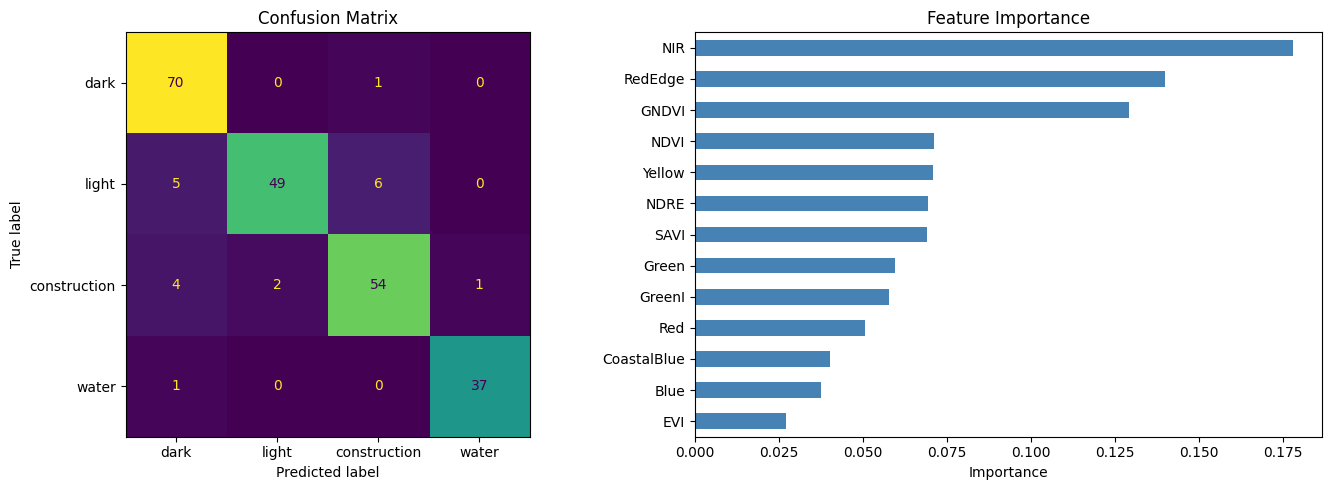

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['dark', 'light', 'construction','water'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

#  Feature importance
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
# create a new raster to classify a composite

CLASS_MAP = {
    'construction': 0,
    'water':        1,
    'light':        2,
    'dark':         3,
}

COLORS = {
    0: '#808080',   # construction — grey
    1: '#4444ff',   # water — blue
    2: '#a8d08d',   # light vegetation — light green
    3: '#1a7a1a',   # dark/forest — deep green
}

FEATURE_COLS = BAND_NAMES + ['NDVI', 'NDRE', 'GNDVI', 'EVI', 'SAVI']

def classify_raster_lazy(raster_path, model, chunk_size=512,filename='classified.tif'):
    with rasterio.open(raster_path) as src:
        meta = src.meta.copy()
        H, W = src.height, src.width
        nodata = src.nodata

    out_meta = meta.copy()
    out_meta.update({'count': 1, 'dtype': 'int8', 'nodata': -1})

    with rasterio.open(raster_path) as src, \
         rasterio.open(filename, 'w', **out_meta) as dst:

        # Iterate over the raster in chunk_size x chunk_size windows
        for row_off in range(0, H, chunk_size):
            for col_off in range(0, W, chunk_size):

                print("in loop")

                # Define the window
                window = rasterio.windows.Window(
                    col_off, row_off,
                    min(chunk_size, W - col_off),   # handles edge chunks
                    min(chunk_size, H - row_off)
                )

                # Read only this window
                data = src.read(window=window).astype(float)  # (8, h, w)
                _, h, w = data.shape

                # Build features for this chunk
                bands   = {name: data[i] for i, name in enumerate(BAND_NAMES)}
                indices = compute_indices(bands)

                feature_stack = np.stack(
                    [bands[f] if f in bands else indices[f] for f in FEATURE_COLS],
                    axis=-1
                ).reshape(-1, len(FEATURE_COLS))

                # Nodata mask
                if nodata is not None:
                    valid_mask = ~np.any(data == nodata, axis=0).ravel()
                else:
                    valid_mask = np.ones(h * w, dtype=bool)

                # Predict
                predictions = np.full(h * w, -1, dtype=np.int8)
                if valid_mask.any():
                    predictions[valid_mask] = [
                        CLASS_MAP[c] for c in model.predict(feature_stack[valid_mask])
                    ]

                # Write this chunk to output
                dst.write(predictions.reshape(1, h, w), window=window)

            print(f"  Processing row {row_off}/{H}...", end='\r')

    print(f"Done! Saved {filename}")

# classify_raster_lazy(composite_2026, rf, chunk_size=8192)

In [ ]:
classify_raster_lazy(composite_2021,rf,chunk_size=2048,filename='classified_2021.tif')

in loop
in loop
in loop
in loop
in loop
in loop
in loop
in loop
in loop
Done! Saved classified_2021.tif


In [ ]:
# paths for clipped classified files
clipped_classified_2021 = '/content/drive/My Drive/urbangreen/clipped-classified-2021.tif'
clipped_classified_2023 = '/content/drive/My Drive/urbangreen/clipped-classified-2023.tif'
clipped_classified_2024 = '/content/drive/My Drive/urbangreen/clipped-classified-2024.tif'
clipped_classified_2025 = '/content/drive/My Drive/urbangreen/clipped-classified-2025.tif'
clipped_classified_2026 = '/content/drive/My Drive/urbangreen/clipped-classified-2026.tif'

In [ ]:
# statistics
YEARS = [2021, 2023, 2024, 2025, 2026]
RASTER_PATHS = {
    2021: clipped_classified_2021,
    2023: clipped_classified_2023,
    2024: clipped_classified_2024,
    2025: clipped_classified_2025,
    2026: clipped_classified_2026
}

pixel_area_m2 = 3 * 3  # 3m resolution

CLASS_LABELS = {
    0: 'Construction',
    1: 'Water',
    2: 'Light Vegetation',
    3: 'Forest'
}

rows = []
for year in YEARS:
    data = rasterio.open(RASTER_PATHS[year]).read(1)
    row = {'year': year}
    for val, label in CLASS_LABELS.items():
        area_km2 = np.sum(data == val) * pixel_area_m2 / 1e6
        row[label] = area_km2
    row['Total Green'] = row['Light Vegetation'] + row['Forest']
    rows.append(row)

area_df = pd.DataFrame(rows).set_index('year')
area_df.drop(columns=['Construction'],inplace=True)

area_df.round(2)

,Water,Light Vegetation,Forest,Total Green
year,,,,
2021,2.40,45.77,42.10,87.87
2023,1.75,59.85,34.77,94.62
2024,2.13,54.55,44.43,98.98
2025,1.88,69.18,31.50,100.68
2026,2.84,36.49,43.39,79.88


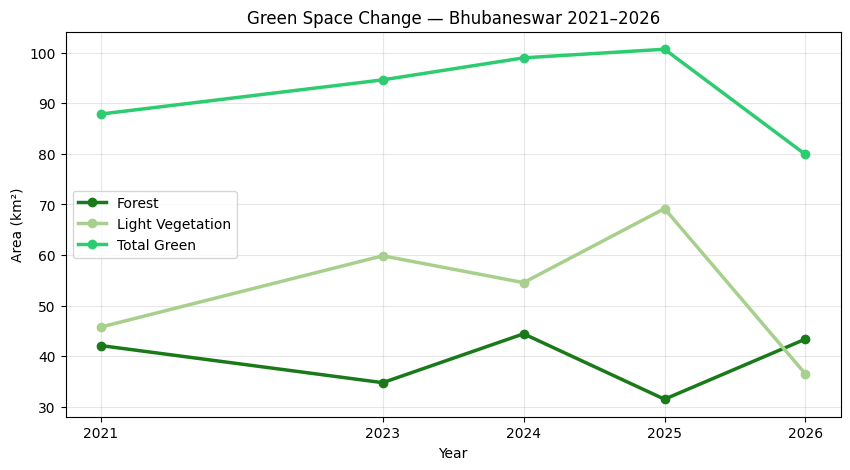

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for col, color in [('Forest', '#1a7a1a'), ('Light Vegetation', '#a8d08d'), ('Total Green', '#2ecc71')]:
    ax.plot(YEARS, area_df[col], marker='o', linewidth=2.5, color=color, label=col)

ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")
ax.set_title("Green Space Change — Bhubaneswar 2021–2026")
ax.legend()
ax.set_xticks(YEARS)
ax.grid(True, alpha=0.3)
plt.show()

                  Construction   Water  Light Vegetation   Forest
Construction           5009424  125954            322064   760516
Water                    62231  144972             22614    36476
Light Vegetation       1416248   18651           2775407   874900
Forest                  628322   25329            891284  3132939


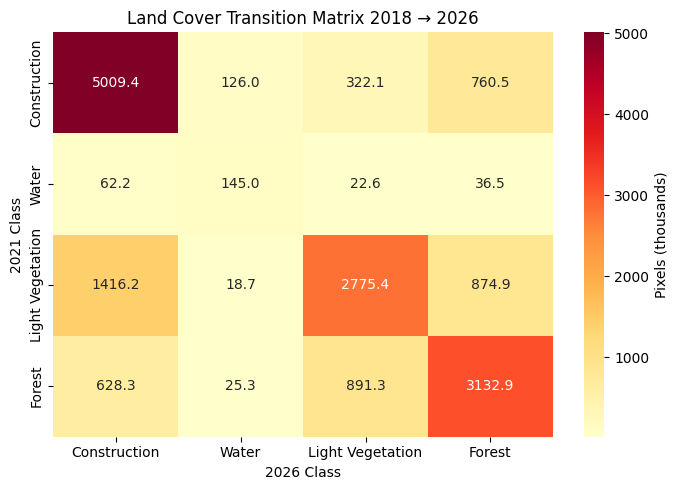

In [ ]:
def transition_matrix(map_a, map_b):
    n = len(CLASS_LABELS)
    matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            matrix[i, j] = np.sum((map_a == i) & (map_b == j))
    labels = list(CLASS_LABELS.values())
    return pd.DataFrame(matrix, index=labels, columns=labels)

# Compare 2018 vs 2026
src_2021 = rasterio.open(clipped_classified_2021).read(1)
src_2026 = rasterio.open(clipped_classified_2026).read(1)
trans = transition_matrix(src_2021,src_2026)
print(trans)

# Visualise
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans / 1000, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Pixels (thousands)'}, ax=ax)
ax.set_xlabel("2026 Class")
ax.set_ylabel("2021 Class")
ax.set_title("Land Cover Transition Matrix 2018 → 2026")
plt.tight_layout()
plt.show()